### Analysing Marketing Campaigns Data

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Que1. see data

In [106]:
df=pd.read_csv('../../Data_Files/Project_sample_Data/marketing_data.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP


### Que2. Types of columns

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4    Income              2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   int64 
 16  NumWeb

### Ques is their any missing data

In [73]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
 Income                24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64

### Which columns are numerical and which are categorical

In [74]:
df.select_dtypes('number').sample(10)

,ID,Year_Birth,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain
39,3767,1968,0,1,1,378,0,189,97,172,...,5,12,3,0,0,0,0,0,0,0
1648,176,1980,0,1,73,90,38,67,33,36,...,1,6,3,0,0,0,0,0,0,0
598,4141,1965,0,0,26,426,49,127,111,21,...,2,10,4,0,0,0,0,0,0,0
976,6872,1974,0,1,43,284,3,84,4,7,...,2,8,4,0,0,0,0,0,0,0
1058,203,1975,0,0,47,1288,20,613,80,61,...,7,9,2,0,0,0,0,0,0,0
1056,3075,1972,0,0,47,130,30,168,20,34,...,4,7,1,0,0,0,0,0,0,0
1014,9624,1958,0,0,46,603,45,207,36,18,...,4,6,1,0,0,0,0,0,0,0
423,6409,1967,0,0,18,267,140,599,34,12,...,5,7,6,0,0,0,0,0,1,0
1253,8286,1965,0,1,55,98,1,17,0,1,...,0,4,7,0,1,0,0,0,0,0
1863,5079,1971,1,1,82,71,1,16,0,0,...,1,3,8,0,0,0,0,0,0,0


In [75]:
df.select_dtypes(['category','object']).sample(10)

,Education,Marital_Status,Income,Dt_Customer,Country
1993,Master,Divorced,"$59,432.00",4/13/13,SP
1145,Master,Married,"$54,348.00",6/8/14,CA
573,PhD,Widow,"$50,520.00",1/28/14,SP
589,Master,Together,"$58,656.00",9/20/12,SP
1075,Graduation,Married,"$42,691.00",8/16/13,SP
1161,2n Cycle,Divorced,"$78,353.00",4/16/13,CA
75,Graduation,Together,"$75,276.00",9/27/12,SP
1436,PhD,Single,"$52,614.00",12/1/12,ME
492,PhD,Together,"$62,981.00",3/17/13,CA
1338,Graduation,Single,"$91,700.00",1/17/13,SP


In [76]:
df[' Income '].isna().sum()

np.int64(24)

Here income is in Object- we need to convert it into float64

In [109]:
df[' Income ']= df[' Income '].str.strip().str.replace('$','', regex=False).str.replace(',','', regex=False).pipe(pd.to_numeric, errors='coerce')

(array([1.654e+03, 5.540e+02, 7.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([  1730. ,  68223.6, 134717.2, 201210.8, 267704.4, 334198. ,
        400691.6, 467185.2, 533678.8, 600172.4, 666666. ]),
 <BarContainer object of 10 artists>)

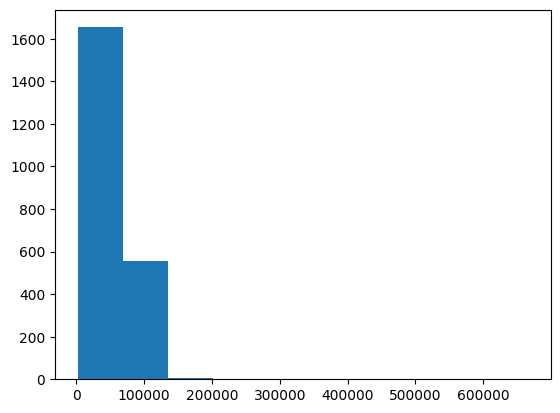

In [110]:
# it has outlier
plt.hist(df[' Income '])

In [111]:
df[' Income '].dtype

dtype('float64')

In [112]:
df[' Income '].max

<bound method Series.max of 0       84835.0
1       57091.0
2       67267.0
3       32474.0
4       21474.0
         ...   
2235    66476.0
2236    31056.0
2237    46310.0
2238    65819.0
2239    94871.0
Name:  Income , Length: 2240, dtype: float64>

check the range of income

(array([ 242.,  818., 1143.,    5.,    0.,    7.,    0.]),
 array([     0.,  25000.,  50000., 100000., 125000., 150000., 175000.,
        200000.]),
 <BarContainer object of 7 artists>)

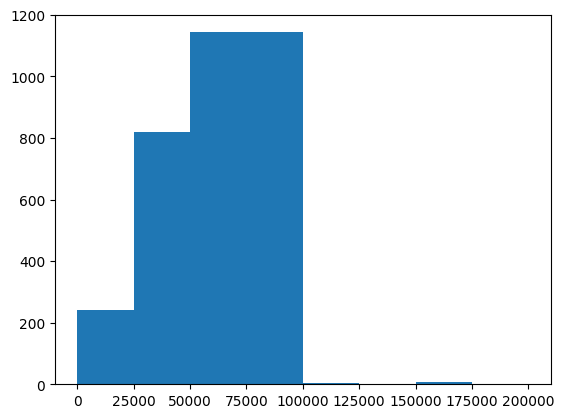

In [113]:
plt.hist(df[' Income '],bins=[0,25000,50000, 100000,125000,150000,175000,200000]) 

Fill the missing income data based on the Education mean

First we calculate mean and median of Income based on the Education by grouping data based on Educations 

In [114]:
df.groupby('Education')[' Income '].mean()

Education
2n Cycle      47633.190000
Basic         20306.259259
Graduation    52720.373656
Master        52917.534247
PhD           56145.313929
Name:  Income , dtype: float64

In [115]:
df.groupby('Education')[' Income '].median()

Education
2n Cycle      46805.0
Basic         20744.0
Graduation    52028.5
Master        50943.0
PhD           55212.0
Name:  Income , dtype: float64

After plotting scatter plot plt.scatter(df['Year_Birth'],df[' Income ']) we found Income has outlier 

In [ ]:
# outlier detection by removing edge cases 0.01 and 0.99 
q1= df[' Income '].quantile(0.01)
q99= df[' Income '].quantile(0.99)

df[' Income ']= df[' Income '].clip(lower=q1, upper=q99)

In [121]:
df.groupby('Education')[' Income '].mean()

Education
2n Cycle      47624.333000
Basic         20309.192593
Graduation    52089.920251
Master        52723.528219
PhD           55561.189605
Name:  Income , dtype: float64

In [122]:
df.groupby('Education')[' Income '].median()

Education
2n Cycle      46805.0
Basic         20744.0
Graduation    52028.5
Master        50943.0
PhD           55212.0
Name:  Income , dtype: float64

Fill all missing values based after removing outlier

In [123]:
df[' Income '] = df.groupby('Education')[' Income '].transform(lambda x : x.fillna(x.median()))

In [104]:
df[' Income '].isna().sum()

np.int64(0)

show relation between Income and Year_Birth

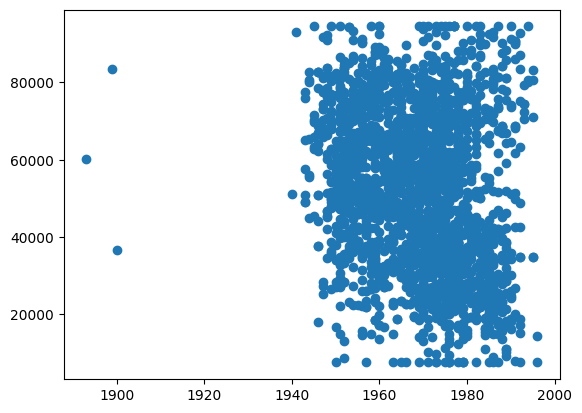

In [124]:
plt.scatter(df['Year_Birth'],df[' Income '])

QUes : Show how many people are in diff education

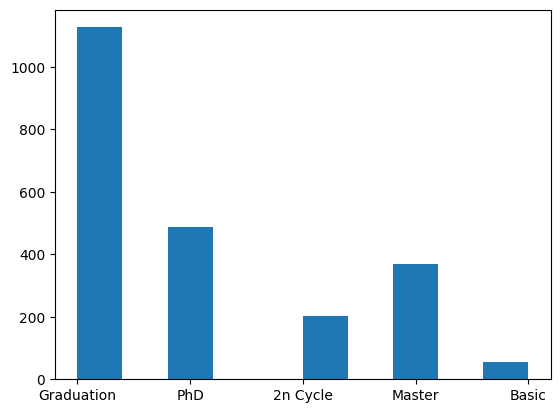

In [ ]:
plt.hist(df['Education'])

plt.show()

In [136]:
df['Education'].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

Ques : Is their any relation in Education and Income

In [ ]:
df['Country'].value_counts()

Country
SP     1095
SA      337
CA      268
AUS     160
IND     148
GER     120
US      109
ME        3
Name: count, dtype: int64